# ⚛️ TrackLab — User Guide: Workflows & Analysis Modes

Welcome to the **TrackLab User Guide**. This interactive notebook walks you through the physical modeling capabilities of TrackLab. You will learn how the physics engine works, how to use the different analysis modes, and how to run simulations both via the **Graphical User Interface (GUI)** and programmatically using **Python**.

### Table of Contents
1. **Section 1**: [Plotting and Comparing V(y) Etch-Rate Curves](#section1)
2. **Section 2**: [Setting the Simulation Configuration](#section2)
3. **Section 3**: [Single Track Simulation & Visualization](#section3)
4. **Section 4**: [Generating and Using Look-Up Tables (LUT)](#section4)
5. **Section 5**: [Processing Monte Carlo (FLUKA) Simulations](#section5)
6. **Section 6**: [Advanced Multi-Ion FLUKA Processing (Beta)](#section6)

---

### How to Run TrackLab

To run TrackLab, you need Python installed on your computer.

1. **Install dependencies**: `pip install -e .`
2. **Launch the GUI**: `python run_gui.py`

See **`HOW_TO_RUN_TRACKLAB.txt`** in the project root for more details.

> **First time opening the app?**
> A **Configuration Summary** popup will appear showing the active V(y) physics models.
> Read it before running any simulation.
> You can always revisit it via **Help -> Show Configuration Summary** (shortcut: F1).


In [1]:
import sys
import os

# Ensure the TrackLab package root is accessible
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

<a id="section1"></a>
## 📊 Section 1: Plotting and Comparing V(y) Etch-Rate Curves

The reduced etch-rate ratio $V(y) = V_T(y)/V_B$ describes the ratio of the track etch rate ($V_T$) to the bulk etch rate ($V_B$) along the particle trajectory, as a function of the residual range $y$.

### 🖥️ GUI Usage (Mode 1: V(y) Explorer)
1. Launch the GUI with `python run_gui.py`.
2. Navigate to the **1: V(y) Curve** tab.
3. Select the ion from the dropdown menu (e.g., `protons`, `C`, `Li`, etc.).
4. Enter the particle energy and click **Calculate** to see the curve overlaid with literature models.

### 💻 Programmatic Usage
Let's plot the $V(y)$ curves for Protons, Lithium, and Carbon using the TrackLab API:

[VTMultiIonModel] Loaded BPL fits from cache: K:\Mele\Software\TRACK_P\Original\Track_p_website_version\old\Backup 6.10 - updated track optics + Github package\Git_package-WIP-Mar2026\combined\track_vision_unified\tracklab\data\bpl_fits_cache.json
[VTMultiIonModel] Applied manual override for C @ 14.8 MeV
[VTMultiIonModel] Applied manual override for C @ 19.2 MeV
[VTMultiIonModel] Applied manual override for C @ 22.5 MeV
[VTMultiIonModel] Applied manual override for C @ 176.56 MeV
[VTMultiIonModel] Applied manual override for O @ 17.26 MeV
[VTMultiIonModel] Applied manual override for O @ 22.23 MeV
[VTMultiIonModel] Applied manual override for O @ 26.41 MeV


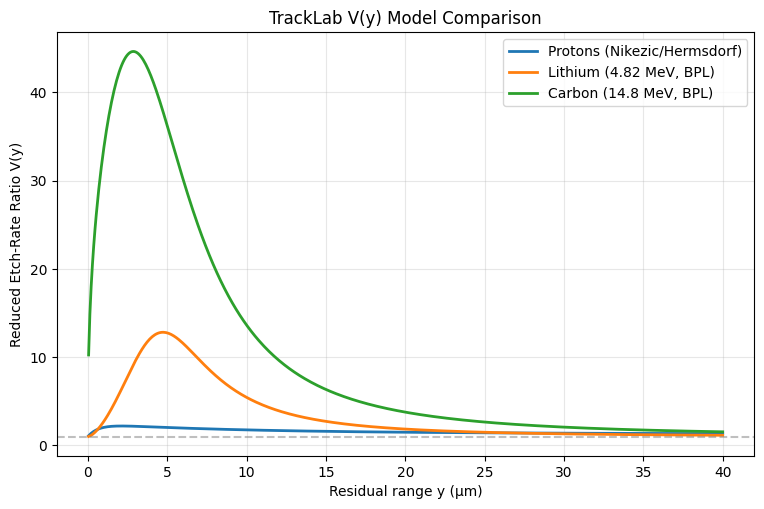

In [2]:
from tracklab.vt_utils import vt_function
from tracklab.vt_multiion import get_model

y = np.linspace(0.05, 40.0, 500)
vt_model = get_model()

# 1. Protons (Nikezic/Hermsdorf analytical model)
v_proton = [float(vt_function(yi)) for yi in y]

# 2. Lithium (Broken Power Law)
v_li = [float(vt_model.V(yi, ion='Li', energy=4.82, vb=1.73)) for yi in y]

# 3. Carbon (Broken Power Law)
v_c = [float(vt_model.V(yi, ion='C', energy=14.8, vb=1.73)) for yi in y]

# Plot the V(y) models
plt.figure(figsize=(9, 5.5))
plt.plot(y, v_proton, label="Protons (Nikezic/Hermsdorf)", lw=2)
plt.plot(y, v_li, label="Lithium (4.82 MeV, BPL)", lw=2)
plt.plot(y, v_c, label="Carbon (14.8 MeV, BPL)", lw=2)
plt.axhline(1, ls="--", color="gray", alpha=0.5)
plt.xlabel("Residual range y (µm)")
plt.ylabel("Reduced Etch-Rate Ratio V(y)")
plt.title("TrackLab V(y) Model Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<a id="section2"></a>
## ⚙️ Section 2: Setting the Simulation Configuration

To run track simulations, you need to define the physical environment parameters:
* **Bulk Etch Rate ($V_B$)**: The rate at which the chemical etchant dissolves the undamaged bulk detector material (typically in $\mu m/h$).
* **Etching Time ($t$)**: The duration of chemical etching (in hours).
* **Initial Energy ($E$)**: The initial kinetic energy of the particle (in MeV).
* **Incidence Angle ($\theta$)**: The angle of entry with respect to the detector surface (in degrees, where $90^\circ$ is normal incidence).

### GUI Configuration
In the GUI, these parameters are located in the **left-hand settings panel** under 'Ion Selection' and 'Physical Parameters'. They apply globally to the active tab.

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

> **Important — V(y) Model Selection:**
> Before running any simulation, confirm which V(y) etch-rate model is active.
> This is the most critical physics choice and affects ALL results:
>
> | Ion | Default model |
> |---|---|
> | Protons | Model 1 — Nikezic / Double-Exponential |
> | Alpha | Model 5 — Hermsdorf (2009) |
> | Li, C, O | Broken Power Law (BPL) — automatic, no selection needed |
>
> To review or change models:
> - Check the **Configuration Summary** popup at startup (or press **F1**)
> - Or go to the **7: Configuration** tab in the main window

### 💻 Programmatic Configuration
Let's see how to retrieve bulk etch rates and load the SRIM range-energy datasets programmatically:

In [3]:
from tracklab.config import get_vb_for_ion
from tracklab.load_srim_data import load_srim_data

# Retrieve default bulk etch rates (VB) for different ions
for ion in ['protons', 'alpha', 'Li', 'C', 'O']:
    print(f"Default VB for {ion:8s}: {get_vb_for_ion(ion):.2f} µm/h")

# Load precomputed SRIM range-energy databases
range_tables, _ = load_srim_data()
print("\nSRIM database loaded. Available ions:", list(range_tables.keys()))

Default VB for protons : 4.70 µm/h
Default VB for alpha   : 1.73 µm/h
Default VB for Li      : 1.73 µm/h
Default VB for C       : 1.73 µm/h
Default VB for O       : 1.73 µm/h
  [OK] protons :  92 points, 0.010–6000.000 MeV, 0.193–99823451.189 µm
  [OK] Li      :  79 points, 0.010–6000.000 MeV, 0.101–120348.027 µm
  [OK] C       : 114 points, 0.010–6000.000 MeV, 0.043–317571.834 µm
  [OK] O       : 131 points, 0.010–6000.000 MeV, 0.033–166856.576 µm
  [OK] alpha   :  79 points, 0.010–6000.000 MeV, 0.139–2478848.203 µm

SRIM database loaded. Available ions: ['protons', 'Li', 'C', 'O', 'alpha']


<a id="section3"></a>
## 🔍 Section 3: Single Track Simulation & Visualization

This mode allows you to simulate the development of a single particle track and analyze its resulting morphology.

### 🖥️ GUI Usage (Mode 2: Single Track)
1. Navigate to the **2: Single Track** tab.
2. Adjust parameters in the left panel (e.g., Proton, 1.5 MeV, 75° angle, $t = 2.83$ h).
3. Click **Calculate Track**.
4. The GUI displays:
   * **3D View**: An interactive 3D model of the track cavity.
   * **XY Microscope View**: A top-down optical simulation showing the track's contrast as seen under a transmission microscope.
   * **YZ and XZ Profiles**: Longitudinal cross-sections of the track walls.

### 💻 Programmatic Usage
Let's run a single track simulation programmatically and plot these exact four views:

Track Status: Developed
Depth       : 4.8471 µm
Major Axis  : 10.7126 µm
Minor Axis  : 9.8960 µm
Black Part %: 78.7%


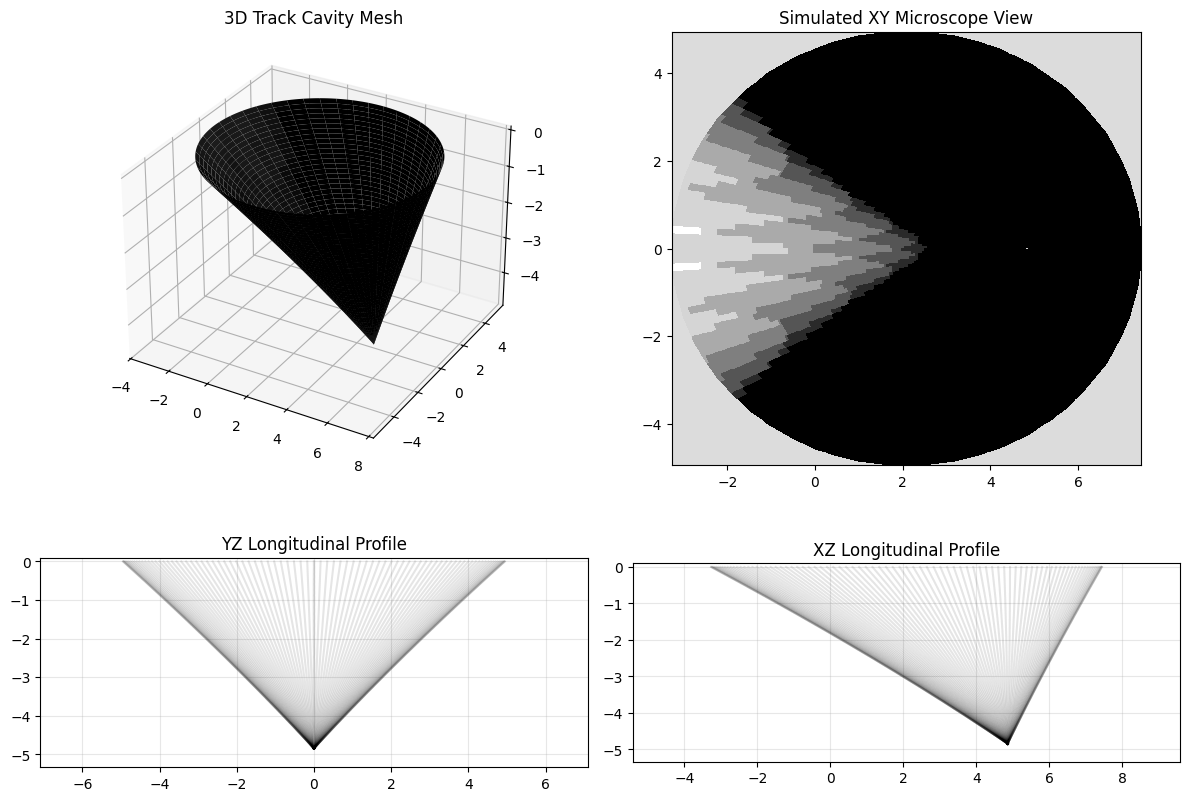

In [4]:
from tracklab.calculate_track_parameter import calculate_track_parameters
from tracklab.vt_utils import build_vrint_interpolator

# Configure track simulation
ion = 'protons'
energy = 1.5    # MeV
angle = 75.0    # degrees
vb = get_vb_for_ion(ion)      # 4.7 µm/h
time_etching = 2.83           # hours

# Load SRIM range interpolator
range_interp = range_tables[ion]

# Build the precomputed V(y) integral interpolator (speeds up geometry calculations)
F_interp = build_vrint_interpolator(vt_model=vt_model, ion=ion, energy=energy, vb=vb)

# Compute track parameters
result = calculate_track_parameters(
    energy=energy,
    angle_deg=angle,
    vb=vb,
    time_etching=time_etching,
    range_interpolator=range_interp,
    F_interp=F_interp,
    ion=ion,
    vt_model=vt_model,
)

print(f"Track Status: {result['status']}")
print(f"Depth       : {result['depth_um']:.4f} µm")
print(f"Major Axis  : {result['major_axis_um']:.4f} µm")
print(f"Minor Axis  : {result['minor_axis_um']:.4f} µm")
print(f"Black Part %: {result['black_part']*100:.1f}%")

# Plotting the 4-panel figure
if result['X_surf'] is not None:
    X, Y, Z = result['X_surf'], result['Y_surf'], result['Z_surf']
    B = result['B_faces'] # Microscope brightness matrix
    
    fig = plt.figure(figsize=(12, 9))
    
    # 3D View
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    if B is not None:
        ax1.plot_surface(X, Y, Z, facecolors=cm.gray(B), linewidth=0, antialiased=True)
    ax1.set_title("3D Track Cavity Mesh")
    
    # XY Microscope View
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.set_facecolor('#DCDCDC')
    if B is not None:
        ax2.pcolormesh(X, Y, B, cmap='gray', shading='flat')
    ax2.set_title("Simulated XY Microscope View")
    ax2.set_aspect('equal')
    
    # YZ Profile
    ax3 = fig.add_subplot(2, 2, 3)
    pad = (X.max() - X.min()) * 0.2
    lim_x = (X.min() - pad, X.max() + pad)
    lim_y = (Y.min() - pad, Y.max() + pad)
    lim_z = (Z.min() * 1.1, 0.1)
    
    ax3.plot(Y, Z, color='black', alpha=0.05)
    y_c = np.append(Y[-1, :], Y[-1, 0])
    z_c = np.append(Z[-1, :], Z[-1, 0])
    ax3.fill(y_c, z_c, color='tab:blue', alpha=0.15)
    ax3.plot(y_c, z_c, color='tab:blue', lw=2)
    ax3.set_xlim(lim_y)
    ax3.set_ylim(lim_z)
    ax3.set_title("YZ Longitudinal Profile")
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal')
    
    # XZ Profile
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(X, Z, color='black', alpha=0.05)
    x_c = np.append(X[-1, :], X[-1, 0])
    z_c4 = np.append(Z[-1, :], Z[-1, 0])
    ax4.fill(x_c, z_c4, color='tab:blue', alpha=0.15)
    ax4.plot(x_c, z_c4, color='tab:blue', lw=2)
    ax4.set_xlim(lim_x)
    ax4.set_ylim(lim_z)
    ax4.set_title("XZ Longitudinal Profile")
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

<a id="section4"></a>
## 🗄️ Section 4: Generating and Using Look-Up Tables (LUT)

Generating individual tracks is physically detailed but computationally expensive because of numerical integration and vector ray tracing. To process millions of particles, we precompute a **Look-Up Table (LUT)** in a grid of energy and angles, and then use **fast interpolation** to look up track parameters in milliseconds.

### 🖥️ GUI Usage (Mode 3 & Mode 6)
* **Mode 3 (Reference LUT)**: Go to the **3: Reference Dataset** tab, enter energy/angle ranges, and click **Generate** to export a CSV.
* **Mode 6 (LUT Simulation)**: Go to the **6: LUT Simulation** tab, load the generated CSV, and query track properties instantly or run inverse queries (finding energy/angle from track size).

### 💻 Programmatic Usage
Let's see how to generate a small LUT and query/interpolate values from it using `LUTEngine`:

In [5]:
from tracklab.lut_engine import LUTEngine

# Let's generate a tiny reference dataset programmatically
print("Generating tiny LUT...")
energies = np.linspace(1.0, 3.0, 5) # 5 energies
angles = np.linspace(60, 90, 4)     # 4 angles

lut_data = []
for energy in energies:
    F_interp = build_vrint_interpolator(vt_model=vt_model, ion='protons', energy=energy, vb=4.7)
    for angle in angles:
        res = calculate_track_parameters(
            energy=energy, angle_deg=angle, vb=4.7, time_etching=3.0,
            range_interpolator=range_tables['protons'], F_interp=F_interp,
            ion='protons', vt_model=vt_model
        )
        lut_data.append({
            'ion': 'protons',
            'energy_MeV': energy,
            'angle_deg': angle,
            'depth_um': res['depth_um'],
            'major_axis_um': res['major_axis_um'],
            'minor_axis_um': res['minor_axis_um'],
            'total_length_um': res['total_length_um'],
            'black_part': res['black_part'],
            'total_surface': res['total_surface'],
            'status': res['status']
        })

# Save to a temporary CSV
lut_df = pd.DataFrame(lut_data)
csv_path = 'tiny_lut_example.csv'
lut_df.to_csv(csv_path, index=False)
print(f"Saved database with {len(lut_df)} tracks to {csv_path}")

# Load the LUT using TrackLab's LUT Engine for instantaneous interpolation
engine = LUTEngine(csv_path)
print("LUT Engine loaded successfully.")

# Query a value that is NOT in the grid (e.g. Energy=2.2 MeV, Angle=72 degrees)
query_res = engine.query(2.2, 72.0)
print(f"\nInterpolated query (Energy=2.2 MeV, Angle=72°):")
print(f"  Major axis: {query_res['major_axis_um']:.4f} µm")
print(f"  Minor axis: {query_res['minor_axis_um']:.4f} µm")
print(f"  Depth:      {query_res['depth_um']:.4f} µm")

# Clean up
if os.path.exists(csv_path):
    os.remove(csv_path)


Generating tiny LUT...


Saved database with 20 tracks to tiny_lut_example.csv
LUT Engine loaded successfully.

Interpolated query (Energy=2.2 MeV, Angle=72°):
  Major axis: 9.9741 µm
  Minor axis: 8.5172 µm
  Depth:      3.0234 µm


<a id="section5"></a>
## 🚀 Section 5: Processing Monte Carlo (FLUKA) Simulations

A major feature of TrackLab is the ability to process full phase-space output files from Monte Carlo codes like FLUKA.

### 🖥️ GUI Usage (Mode 4: FLUKA Process)
1. Navigate to the **4: FLUKA Process** tab.
2. Click **Browse** and select the input file (e.g., `AmBe_01001_Phase-space_BXDRAW.txt`).
3. Click **Process File**.
4. The GUI reads the particle coordinates and direction cosines, computes the entry angle and corrected etching time (reducing etching time if the particle started below the detector surface), and outputs a CSV containing track dimensions for all developed tracks.

### 💻 Programmatic Usage
Let's see how to parse a FLUKA phase-space file programmatically and examine the first few processed tracks:

Processing FLUKA file subset...

Mode 4: FLUKA Processing for protons
  File: temp_fluka_subset.txt
  [OK] protons :  92 points, 0.010–6000.000 MeV, 0.193–99823451.189 µm
  [OK] Li      :  79 points, 0.010–6000.000 MeV, 0.101–120348.027 µm
  [OK] C       : 114 points, 0.010–6000.000 MeV, 0.043–317571.834 µm
  [OK] O       : 131 points, 0.010–6000.000 MeV, 0.033–166856.576 µm
  [OK] alpha   :  79 points, 0.010–6000.000 MeV, 0.139–2478848.203 µm
  249 particles


  24/249


  48/249


  72/249


  96/249


...

  192/249


  216/249


  240/249



  Processed: 247  Developed: 173  Skipped: 2
  Saved to: fluka_processed_results.csv

Processed Tracks Sample:


,energy_MeV,angle_deg,depth_um,major_axis_um,minor_axis_um,total_length_um,status
0,2.770329,75.387780,2.344231,8.326331,7.435950,8.326315,Developed
1,3.864588,79.066393,1.333837,6.317978,5.716143,6.317967,Developed
2,1.098963,63.246831,7.071595,13.166809,10.456663,13.166780,Developed
3,5.103260,75.691791,0.267055,4.276464,2.560859,4.276461,Developed
4,2.076391,64.690356,2.234402,9.876872,7.189061,9.876861,Developed


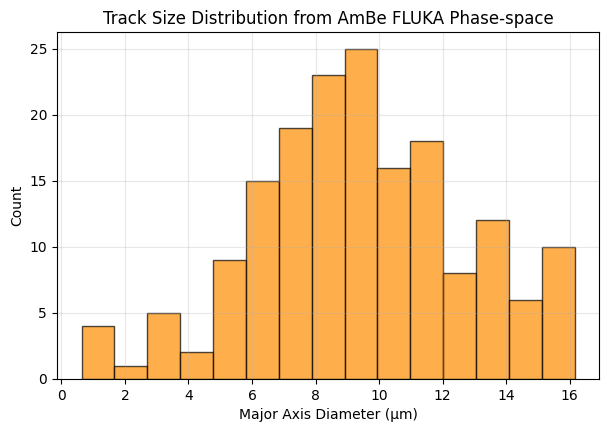

In [6]:
from tracklab.mode_use import run_mode4_fluka

# We'll use a subset of the provided sample FLUKA file to run quickly
fluka_file = r"examples/AmBe_01001_Phase-space_BXDRAW.txt"
temp_file = "temp_fluka_subset.txt"
output_csv = "fluka_processed_results.csv"

if os.path.exists(fluka_file):
    # Read the first 250 lines to create a fast demo subset
    with open(fluka_file, 'r') as f_in:
        lines = [next(f_in) for _ in range(250)]
    with open(temp_file, 'w') as f_out:
        f_out.writelines(lines)
        
    print("Processing FLUKA file subset...")
    results = run_mode4_fluka(
        ion='protons',
        input_file=temp_file,
        vb=4.7,
        time_etching=2.83,
        output_csv=output_csv,
        skip_header=1
    )
    
    # Read and show the first 5 results
    df_results = pd.read_csv(output_csv)
    print("\nProcessed Tracks Sample:")
    display(df_results.head(5))
    
    # Plot the major axis distribution of the developed tracks
    developed_only = df_results[df_results['status'] == 'Developed']
    if len(developed_only) > 0:
        plt.figure(figsize=(7, 4.5))
        plt.hist(developed_only['major_axis_um'], bins=15, color='darkorange', edgecolor='black', alpha=0.7)
        plt.xlabel("Major Axis Diameter (µm)")
        plt.ylabel("Count")
        plt.title("Track Size Distribution from AmBe FLUKA Phase-space")
        plt.grid(True, alpha=0.3)
        plt.show()
    
    # Clean up output and temp file
    if os.path.exists(output_csv):
        os.remove(output_csv)
    if os.path.exists(temp_file):
        os.remove(temp_file)
else:
    print(f"Sample FLUKA file not found at {fluka_file}. Make sure to run the notebook inside the project root directory.")


<a id="section6"></a>
## 🚀 Section 6: Advanced Multi-Ion FLUKA Processing (Beta)

TrackLab now supports an advanced multi-ion processing mode for complex neutron simulations where multiple charged particles are tracked (e.g., protons, alphas, heavy recoils like C, O).

### Using the `mgdraw_beta.f` Routine
Instead of the default Phase-Space output, use the `mgdraw_beta.f` routine (available in `K:\Mele\Software\Fluka\Routines\Subroutine - all ions debug`). This routine generates a single file, `remlayer_events.dat`, containing exactly the start points of all charged particles born inside or crossing the dosimeter layer.

### File Format (`remlayer_events.dat`)
The output has 9 columns:
1. **NCASE**: Event number
2. **Type**: `1`=BORN, `2`=IN_FW, `3`=IN_BW, `4`=STOP_OR_RECOIL
3. **Particle Name**
4. **Z**: Atomic number
5. **A**: Mass number
6. **Kinetic Energy**: [GeV]
7. **Z_POS**: Position [cm]
8. **CZ_DIR**: Direction cosine
9. **Comment**: Origin info

### 🖥️ GUI Usage (Beta Mode)
1. Go to the **4: FLUKA** tab.
2. Load your `remlayer_events.dat` file.
3. Check the box: **Beta: Multi-Ion Mode (Advanced MGDRAW)**.
4. Click **Run Fluka Processing**.
The engine will automatically map the `Z` values to the correct ions (`protons, alpha, Li, C, O`), bypass any single-ion deduplication, and compute the tracks accurately.